# Archetype Crosstalk Network

Adapted from: Adler, M. et al. Emergence of division of labor in tissues through cell interactions and spatial cues. Cell Reports 42, 112412 (2023).

## Packages

In [1]:
import sys
!{sys.executable} -m pip install --quiet decoupler liana requests ipywidgets

/bin/bash: /Users/pschafer/Library/Application: No such file or directory


In [2]:
import os
from pathlib import Path
import requests

import scanpy as sc
import pandas as pd
import numpy as np
import liana as li

import partipy as pt
from partipy.datasets import load_fibroblast_data
from partipy.crosstalk import get_specific_genes_per_archetype, get_archetype_crosstalk, plot_weighted_network

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Data

Subset to fibroblast, and pre-process the single-cell RNA-seq data using scanpy.

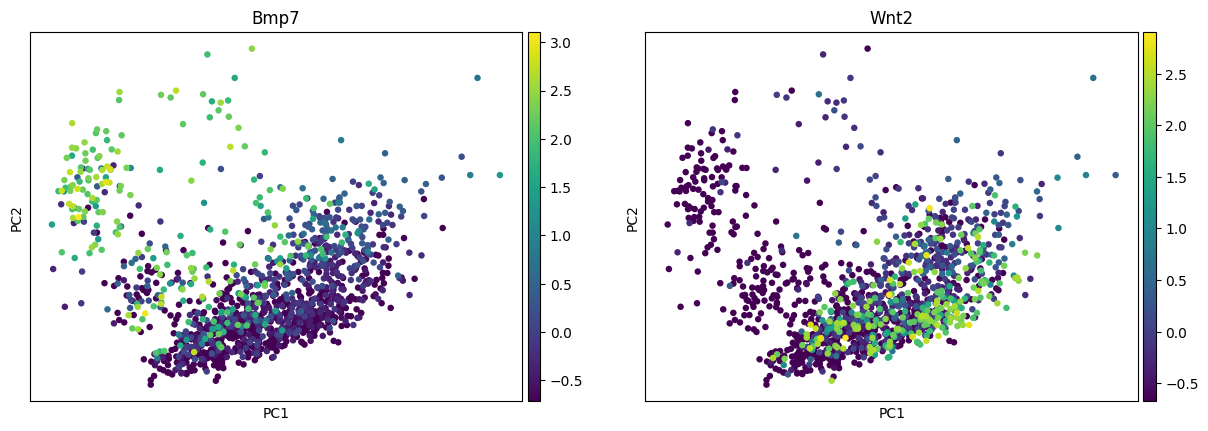

In [3]:
adata = load_fibroblast_data()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
sc.pp.pca(adata, mask_var="highly_variable", n_comps=50)
adata.layers["z_scaled"]= sc.pp.scale(adata.X, max_value=10) # save this for later
sc.pl.pca_scatter(adata, color=["Bmp7", "Wnt2"])

Based on the PCA scree plot, we will be using 8 PC dimensions to fit the archetypes.

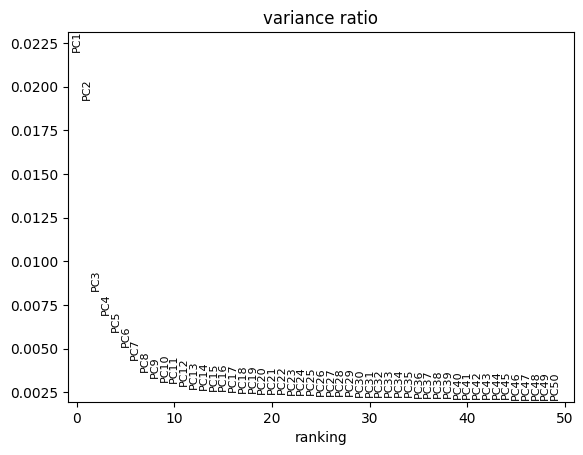

In [4]:
sc.pl.pca_variance_ratio(adata, n_pcs=50)
pt.set_obsm(adata=adata, obsm_key="X_pca", n_dimensions=8)

In [5]:
#var_explained_aa(adata=adata, min_k=2, max_k=10)
#plot_var_explained_aa(adata)

Here, we will use 5 archetypes. When fitting 4 archetypes we have observed that running archetypal analysis on bootstrapped data shows that one archetype is quite unstable, whereas using 5 worked much better.

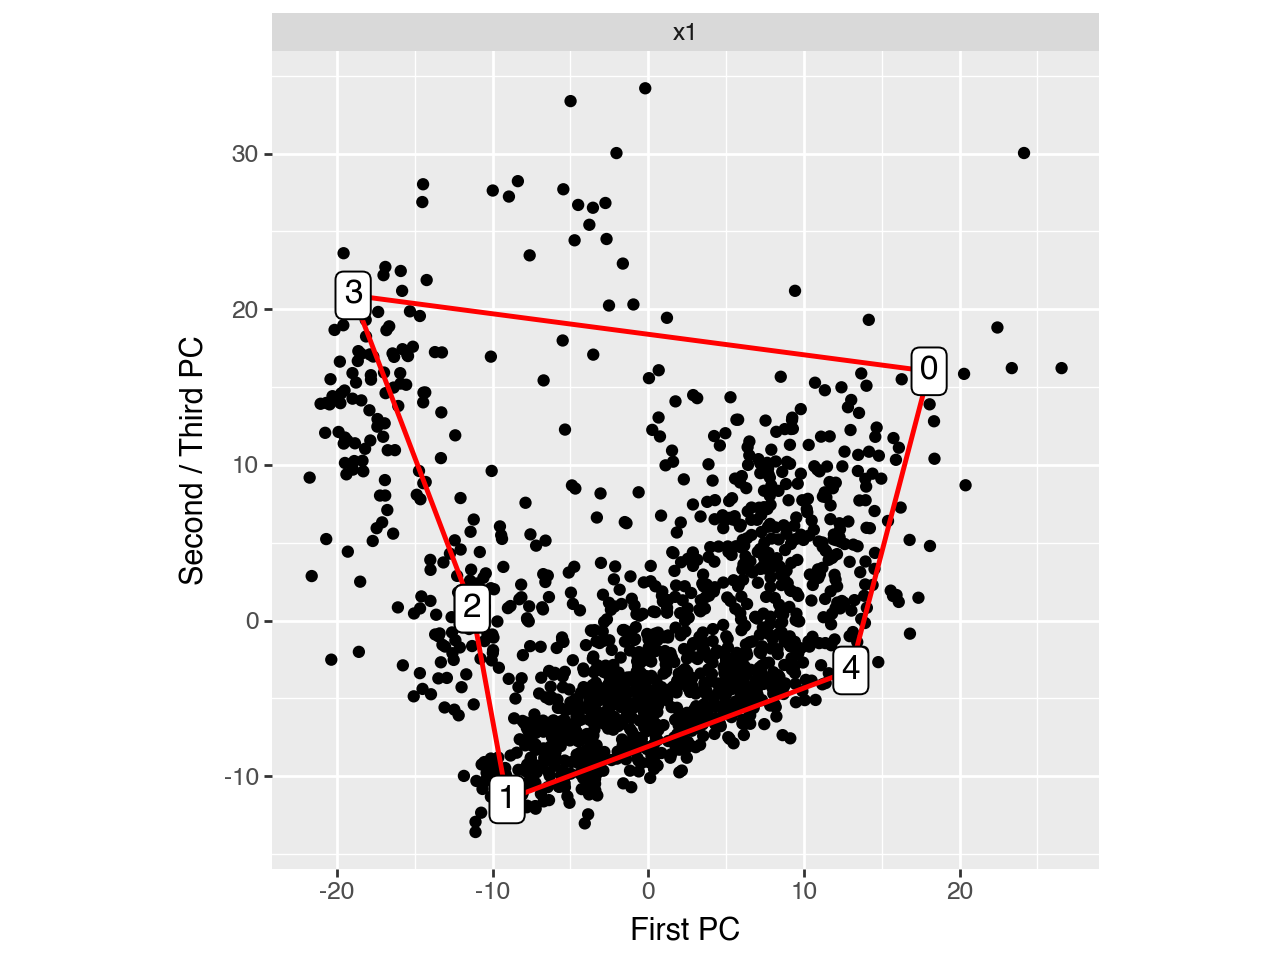

In [6]:
pt.compute_archetypes(adata, n_archetypes=5, verbose=False)
pt.plot_archetypes_2D(adata=adata)

Determine which genes are characteristic for each archetype

Applied length scale is 12.865645415925027.


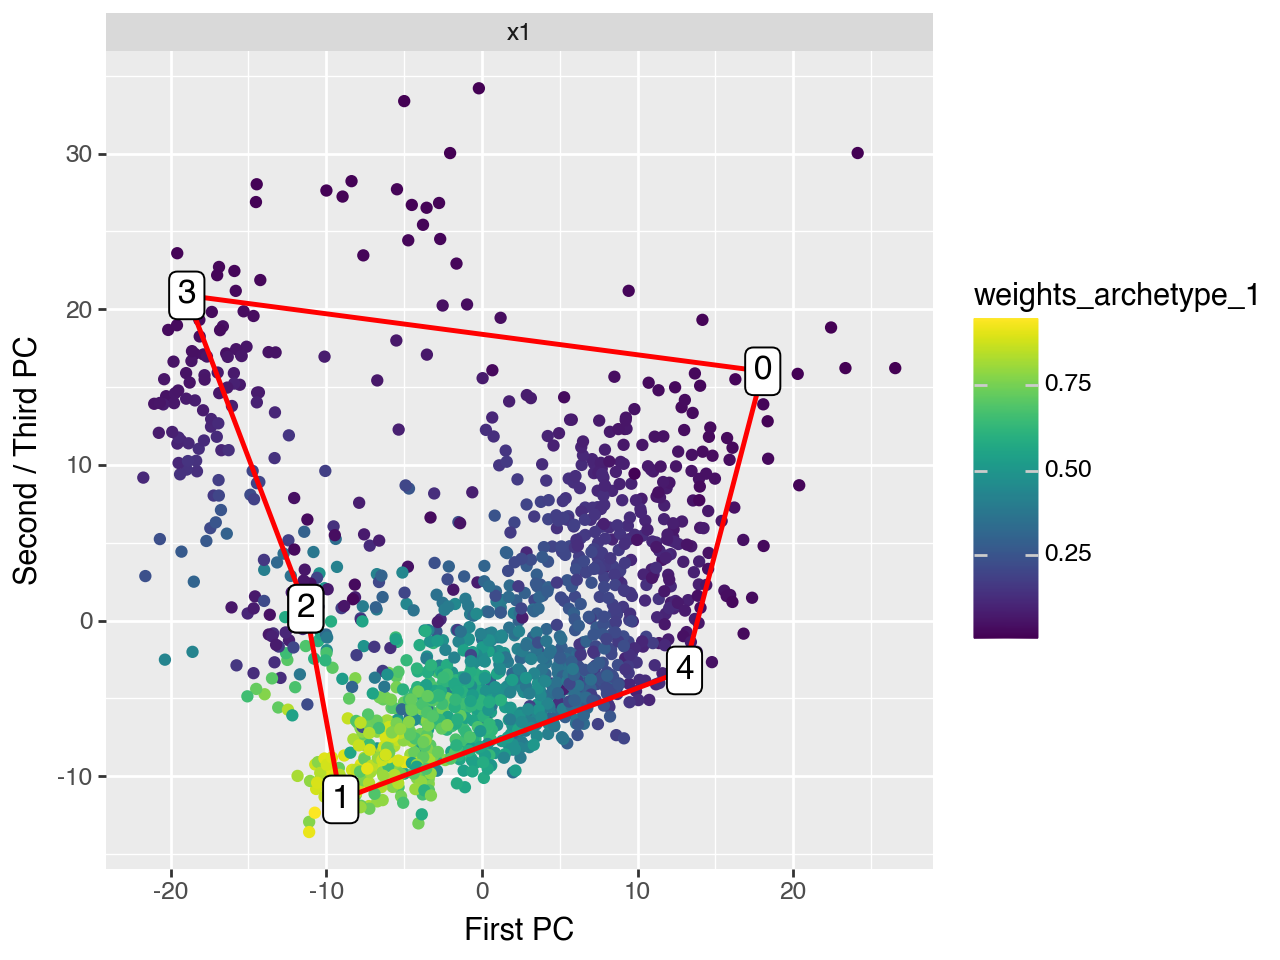

In [7]:
pt.compute_archetype_weights(adata=adata, mode="automatic")
pseudobulk = pt.compute_archetype_expression(adata=adata, layer="z_scaled")

adata.obs["weights_archetype_1"] = adata.obsm["cell_weights"][:, 1]
pt.plot_archetypes_2D(adata=adata, color="weights_archetype_1")

In [8]:
specific_genes_per_archetype = get_specific_genes_per_archetype(archetype_expression=pseudobulk, min_score=0.05)

[(arch_id, len(arch_genes)) for arch_id, arch_genes in specific_genes_per_archetype.items()]

[(0, 5032), (1, 55), (2, 1197), (3, 1888), (4, 1300)]

Based on the genes we infer the functions of each archetype

In [9]:
for i in range(len(specific_genes_per_archetype)):
    print(i, specific_genes_per_archetype[i].head(25)["gene"].to_list())

0 ['Sox18', 'Mmrn2', 'Plvap', 'Tie1', 'Ushbp1', 'Robo4', 'Flt1', 'Emcn', 'Kdr', 'Egfl7', 'Fabp4', 'Dll4', 'Podxl', 'Cd300lg', 'Adgrg1', 'Adgrl4', 'Cd24a', 'Depp1', 'Gdf10', 'Sox17', 'Gimap6', 'Car4', 'Bcam', 'Fam110d', 'Exoc3l2']
1 ['Bcl6', 'Hpse2', 'Serping1', 'Ugcg', 'Ccbe1', 'Dnm3os', 'Edil3', 'Ms4a4b', 'Gm8369', 'Cxcl12', 'D630033O11Rik', 'Rax', 'Gm16263', 'Ces2b', 'Hoxc9', 'Zfp808', 'C1rb', 'Dlx6', 'Gm8730', 'Gsdmc4', 'Gm6569', 'Iglv1', 'Hoxc10', 'Adap2os', 'Gm14391']
2 ['Lmod1', 'Cnn1', 'Actg2', 'Pdgfc', 'Cdh6', 'Itga8', 'Myocd', 'Tagln', 'Asb2', 'Kcnmb1', 'Tnfrsf19', 'Acta1', 'Myh11', 'Trpc6', 'Tspan2', 'Slc2a4', 'Pcp4l1', 'Hspb7', 'Pde6h', 'Gm16000', 'Ctxn1', 'Acta2', 'Ptk2b', 'Hhip', 'E030013I19Rik']
3 ['Cd38', 'Nrg1', '1700071M16Rik', 'Lef1', 'Lef1os1', 'Cdhr17', 'Trpa1', 'Rab3b', 'Pla2g7', 'Lpar3', 'Lama5', 'Ptprr', 'Ano2', 'Cd300e', 'Glp2r', 'C5ar1', 'Sema4d', 'Tbx3', 'Abcc4', 'Cox4i2', 'Tspan13', 'Ano1', 'Procr', 'Eva1a', 'Ednrb']
4 ['Efhd1os', '1700019D03Rik', 'Efhd1', 'C

In [10]:
archetype_functions = {
    0: "ECM-remodeling fibroblasts",
    1: "Vascular-associated fibroblasts",
    2: "Neuronal/epithelial-interacting fibroblasts",
    3: "Myofibroblasts",
    4: "Immune-modulatory fibroblasts"
}

Finally we use [LIANA+](https://liana-py.readthedocs.io/en/latest/) to infer ligand and receptor are enriched between archetypes. But first we need to translate the human ligand-receptor database to mouse gene symbols.

In [11]:
human_resource = li.rs.select_resource('consensus')

# let's say we are interested in zebrafish homologs of human genes
map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_mouse_hcop_fifteen_column.txt.gz',
                                   columns=['human_symbol', 'mouse_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )
# rename the columns to source and target, respectively for the original organism and the target organism
map_df = map_df.rename(columns={'human_symbol':'source', 'mouse_symbol':'target'})

mouse_resource = li.rs.translate_resource(human_resource,
                                          map_df=map_df,
                                          columns=['ligand', 'receptor'],
                                          replace=True,
                                          # NOTE that we need to define the threshold of redundancies for the mapping
                                          # # in this case, we would keep mappings as long as they don't map to more than 2 mouse genes
                                          # one_to_many=3
                                          )
mouse_resource

/Users/pschafer/Library/Application Support/hatch/env/virtual/partipy/U65dndfd/docs/lib/python3.11/site-packages/liana/resource/_orthology.py:199: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


,ligand,receptor
0,Lgals9,Ptprc
1,Lgals9,Met
2,Lgals9,Cd44
3,Lgals9,Lrp1
4,Lgals9,Cd47
...,...,...
4619,Bmp2,Actr2
4620,Bmp15,Actr2
4621,Csf1,Csf3r
4622,Il36g,Ifnar1


In [12]:
archetype_crosstalk = get_archetype_crosstalk(archetype_genes=specific_genes_per_archetype, 
                                              lr_resource=mouse_resource)

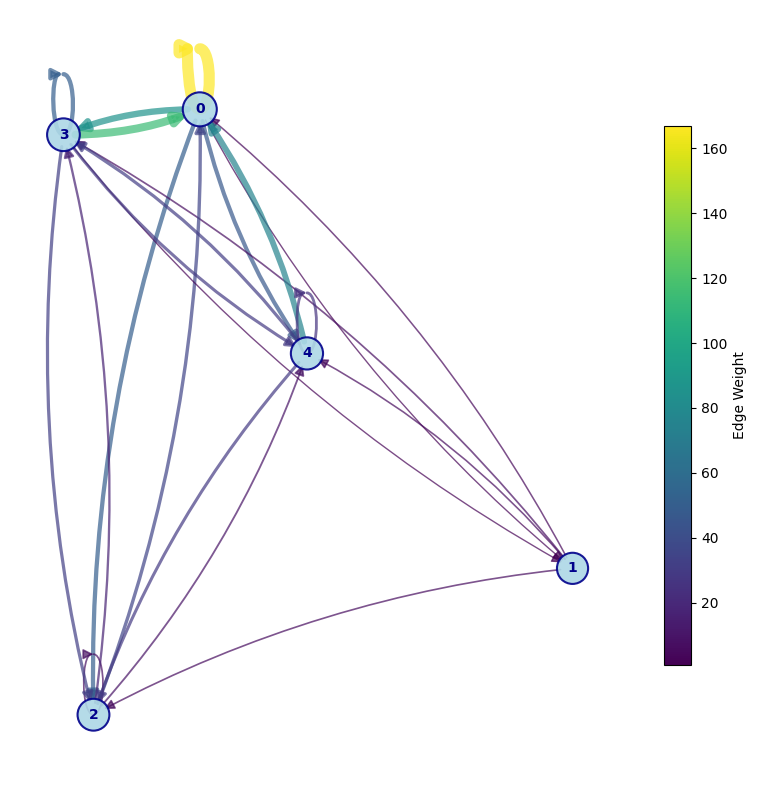

In [13]:
plot_weighted_network(
    specific_genes_per_archetype=specific_genes_per_archetype,
    archetype_crosstalk_dict=archetype_crosstalk,
    layout="spring", seed=42)

## Session Info

In [14]:
import session_info2
print(session_info2.session_info(dependencies=True))

pandas	2.2.3
plotnine	0.14.5
requests	2.32.3
scanpy	1.11.2
numpy	2.2.6
liana	1.5.1
partipy	0.0.1
anndata	0.11.4
----	----
executing	2.2.0
python-dateutil	2.9.0.post0
requests-cache	1.2.1
pytz	2025.2
setuptools	80.9.0
Jinja2	3.1.6
pyzmq	26.4.0
cffi	1.17.1
ipython	9.3.0
tornado	6.5.1
sphinxcontrib-qthelp	2.0.0
xarray	2025.4.0
asttokens	3.0.0
sphinxcontrib-devhelp	2.0.0
future	1.0.0
typing_extensions	4.13.2
charset-normalizer	3.4.2
numcodecs	0.15.1
tqdm	4.67.1
psutil	7.0.0
llvmlite	0.44.0
statsmodels	0.14.4
url-normalize	2.2.1
jedi	0.19.2
cycler	0.12.1
jupyter_client	8.6.3
matplotlib-inline	0.1.7
wcwidth	0.2.13
pure_eval	0.2.3
attrs	25.3.0
numba	0.61.2
sphinxcontrib-applehelp	2.0.0
pillow	11.2.1
patsy	1.0.1
traitlets	5.14.3
cattrs	25.1.0
urllib3	2.4.0
parso	0.8.4
sphinxcontrib-bibtex	2.6.3
dask	2024.11.2
joblib	1.5.1
decorator	5.2.1
session-info2	0.1.2
pexpect	4.9.0
natsort	8.4.0
tabulate	0.9.0
narwhals	1.41.0
scikit-learn	1.6.1
zipp	3.22.0
zarr	2.18.7
defusedxml	0.7.1
docrep	0.3.2
pycpar

/Users/pschafer/Library/Application Support/hatch/env/virtual/partipy/U65dndfd/docs/lib/python3.11/site-packages/session_info2/__init__.py:124: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
